<a href="https://colab.research.google.com/github/JoshEliell/ColabFiles/blob/main/Sesion10_Data_Profiling_Entregable_274705.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 10 — Entregable sobre Data Profiling

**Nombre completo: Victor Joshua Hernandez Ramon**

**Matrícula: 274705**

---

Este notebook contiene las actividades a entregar de la Sesión 10 (Data Profiling), aplicadas sobre **datasets reales**: el catálogo de Netflix y el dataset de Customer Personality Analysis (Kaggle). Si aún no revisaste las explicaciones y ejemplos de cada tema, hazlo primero en el notebook `Sesion10_Data_Profiling_Actividad_Asincrona.ipynb`.

**Nota sobre los datos:** ambos datasets son reales — los problemas de calidad que vas a encontrar (nulos, categorías inconsistentes, valores fuera de rango) ya existían antes de que este notebook los usara. La única excepción está marcada explícitamente en la Actividad 3 y la Práctica integradora, donde se inyectan un par de filas/valores a propósito para poder practicar duplicados y ajuste de tipos con un resultado garantizado.

**Antes de entregar:** ejecuta "Reiniciar y ejecutar todo" para confirmar que tu notebook corre de principio a fin sin errores.

## Preparación

Ejecuta esta celda antes de empezar — descarga los dos datasets reales que vas a usar.

In [22]:
import pandas as pd

url_netflix = 'https://raw.githubusercontent.com/Vibe1990/Netflix-Project/main/netflix_title.csv'
url_marketing = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv'

df_netflix = pd.read_csv(url_netflix)
df_marketing = pd.read_csv(url_marketing, sep=';')  # nota: este archivo usa punto y coma, no coma

print('Netflix:', df_netflix.shape)
print('Marketing:', df_marketing.shape)

Netflix: (7787, 12)
Marketing: (2240, 29)


Imagen informacion url_netflix

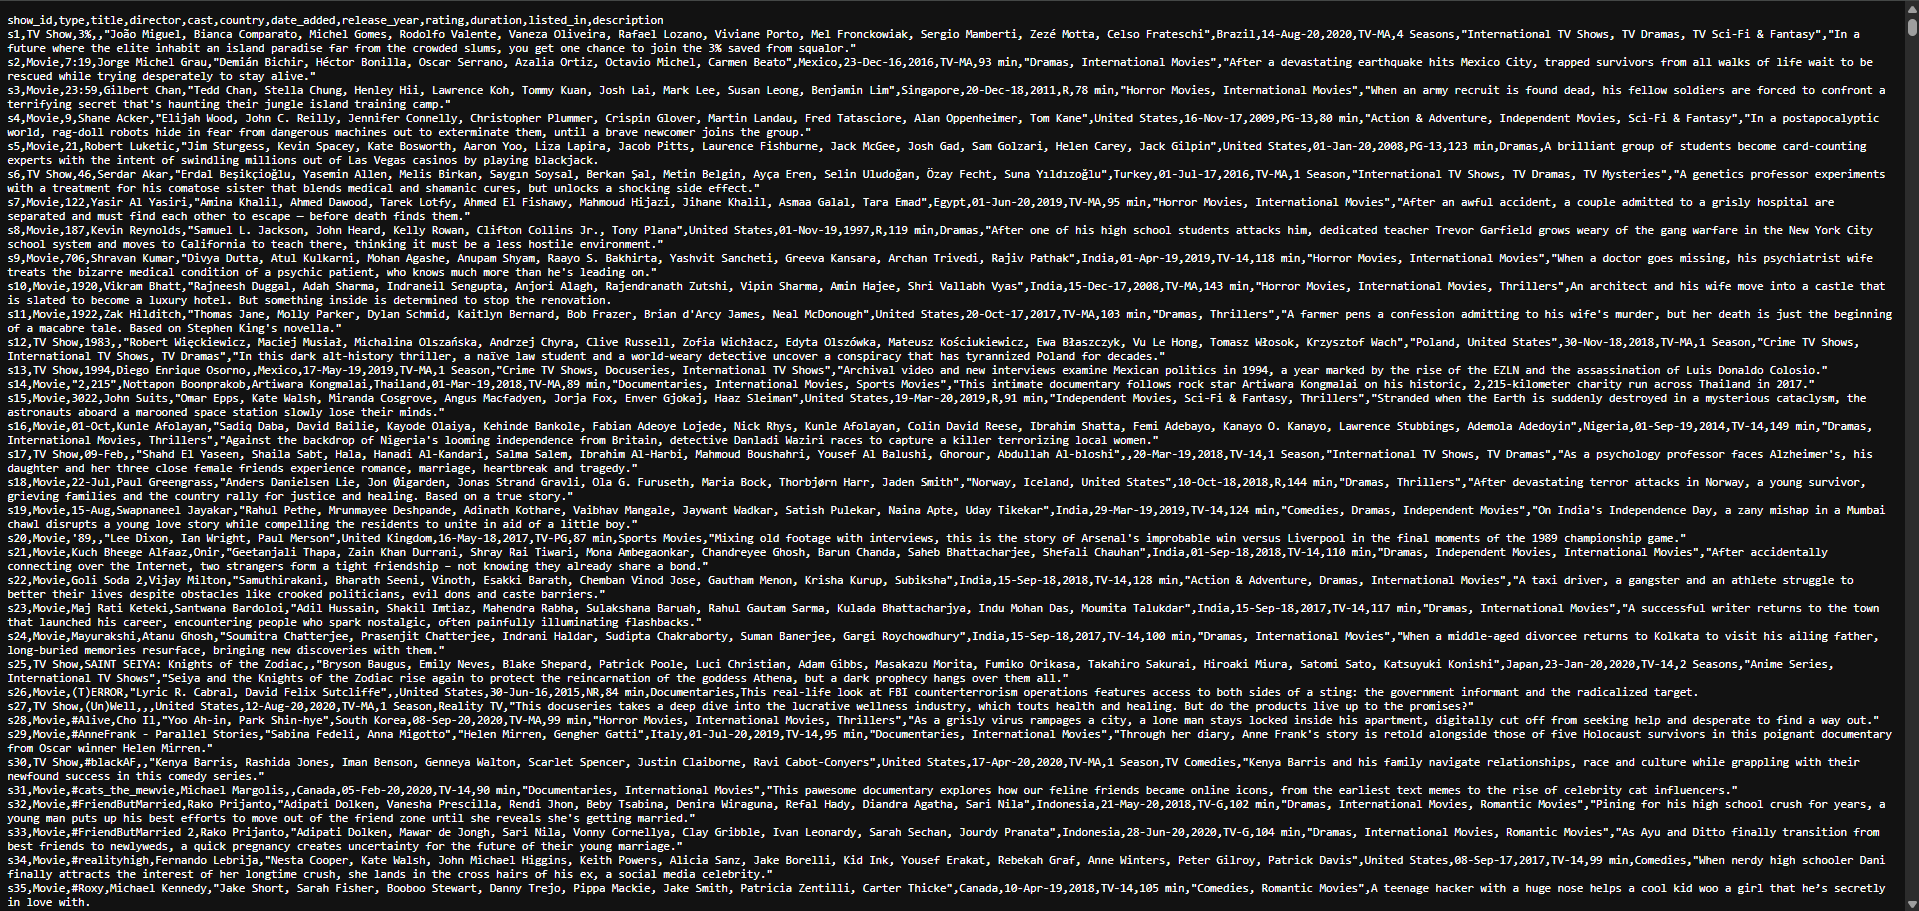

Imagen informacion url_marketing

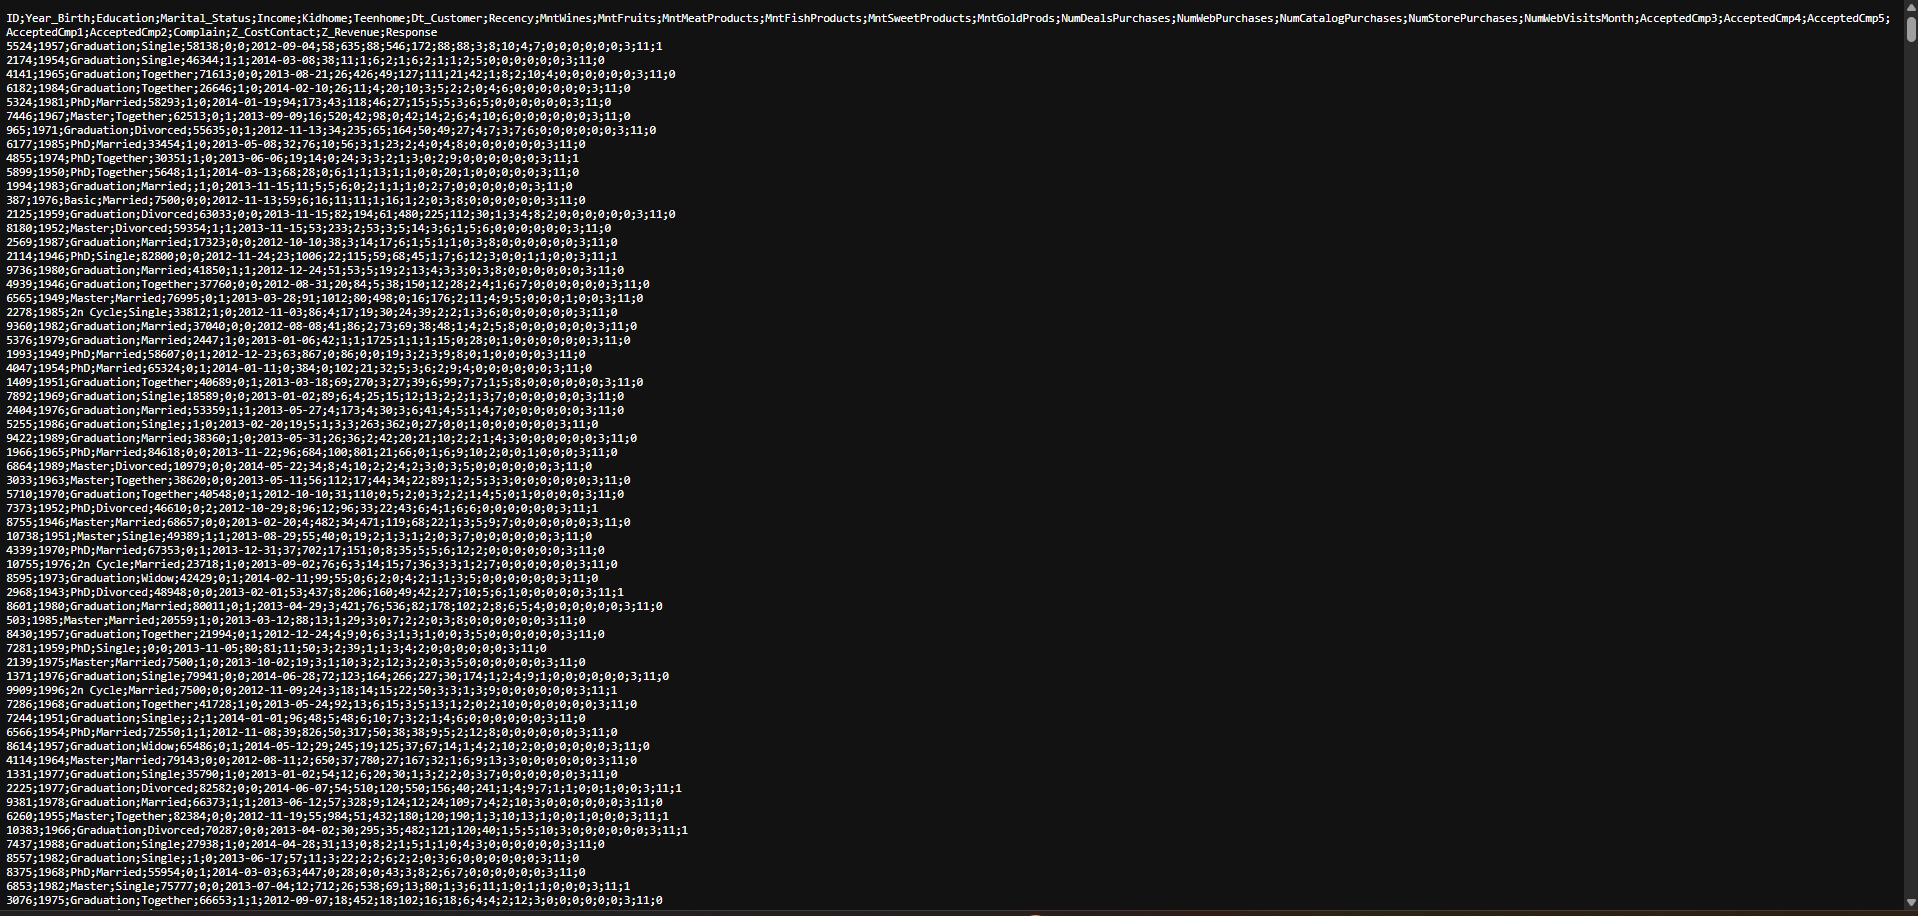

---
## Actividad 1 — Renombrado y estandarización de columnas

*Dataset: Customer Personality Analysis*

Revisa los nombres de columna de `df_marketing` con `.columns`. Vas a notar una mezcla de convenciones reales: `Year_Birth` (con guion bajo), `Kidhome` (sin separador), `MntWines` (abreviado y sin separador).

**Trabaja sobre una copia** (`df_marketing_renombrado = df_marketing.copy()`) para no afectar las actividades siguientes, que usan los nombres originales. Aplica `.str.lower()` para al menos unificar mayúsculas/minúsculas, y usa `.rename()` para corregir manualmente los 2-3 nombres que la técnica automática no deja perfectos (por ejemplo, `mntwines` sigue sin ser ideal — decide tú el nombre final).

In [23]:
# Tu código aquí
df_marketing_renombrado = df_marketing.copy()

# 1. Cambiar todo a minusculas
df_marketing_renombrado.columns = df_marketing_renombrado.columns.str.lower()

# 2. Renombrar manualmente para estandarizar columnas
df_marketing_renombrado = df_marketing_renombrado.rename(columns={
    'year_birth': 'birth_year',
    'kidhome': 'kids_home',
    'mntwines': 'amount_wines',
    'mntfruits': 'amount_fruits',
    'mntmeatproducts': 'amount_meat'
})

print(df_marketing_renombrado.columns)


Index(['id', 'birth_year', 'education', 'marital_status', 'income',
       'kids_home', 'teenhome', 'dt_customer', 'recency', 'amount_wines',
       'amount_fruits', 'amount_meat', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'complain', 'z_costcontact', 'z_revenue', 'response'],
      dtype='object')


---
## Actividad 2 — Ajuste de tipos: fechas con formato mixto

*Dataset: Netflix*

La columna `date_added` de `df_netflix` mezcla formatos reales: la mayoría son `"14-Aug-20"`, pero un grupo minoritario llega como `" August 4, 2017"` (con espacio inicial). Conviértela a tipo fecha usando `pd.to_datetime(..., format='mixed')`, que resuelve ambos formatos en la misma columna. Verifica con `.dtypes` y confirma cuántos valores nulos quedan después de la conversión (compara contra los nulos que ya traía antes de convertir).

In [24]:
# Tu código aquí
print("Nulos antes de la conversión:", df_netflix['date_added'].isnull().sum())

# Convertir a datetime manejando formatos mixtos
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], format='mixed')

print("\nTipos de datos actuales:\n", df_netflix['date_added'].dtypes)
print("\nNulos después de la conversion:", df_netflix['date_added'].isnull().sum())

Nulos antes de la conversión: 10

Tipos de datos actuales:
 datetime64[ns]

Nulos después de la conversion: 10


---
## Actividad 3 — Duplicados

*Dataset: Customer Personality Analysis — con 2 filas duplicadas inyectadas a propósito*

Este dataset real no trae duplicados de forma natural — para poder practicar, se insertan 2 copias de clientes ya existentes (ejecuta la celda siguiente).

In [25]:
df_marketing_dup = pd.concat([df_marketing, df_marketing.sample(2, random_state=7)], ignore_index=True)
print('Filas originales:', len(df_marketing))
print('Filas con duplicados inyectados:', len(df_marketing_dup))

Filas originales: 2240
Filas con duplicados inyectados: 2242


Sobre `df_marketing_dup`: cuenta los duplicados exactos con `.duplicated().sum()`, luego cuenta los duplicados por `ID` con `.duplicated(subset='ID').sum()` (deberían coincidir, ya que el `ID` es único por cliente). Elimínalos con `.drop_duplicates()` y confirma el número final de filas.

In [26]:
# Tu código aquí
# Contar duplicados exactos y por ID
print("Duplicados exactos:", df_marketing_dup.duplicated().sum())
print("Duplicados por ID:", df_marketing_dup.duplicated(subset='ID').sum())

# Eliminar duplicados y confirmar
df_marketing_dup = df_marketing_dup.drop_duplicates()
print("Filas finales:", len(df_marketing_dup))

Duplicados exactos: 2
Duplicados por ID: 2
Filas finales: 2240


---
## Actividad 4 — Valores faltantes

*Dataset: Netflix*

Usa `.isnull().sum()` sobre `df_netflix` para ver cuántos valores faltan por columna. Luego, usa `.isnull().any(axis=1)` para filtrar solo las filas que tienen **al menos un** valor faltante en cualquier columna, y muestra cuántas filas son en total (`.sum()` sobre el resultado booleano).

In [27]:
# Tu código aquí
# Nulos por columna
print("Valores faltantes por columna:\n", df_netflix.isnull().sum())

# Filas con al menos un nulo
filas_con_nulos = df_netflix.isnull().any(axis=1).sum()
print(f"\nTotal de filas con al menos un valor faltante: {filas_con_nulos}")

Valores faltantes por columna:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

Total de filas con al menos un valor faltante: 2979


---
## Actividad 5 — Completitud como porcentaje

*Dataset: Netflix*

Con los mismos nulos de la Actividad 4, calcula la completitud en porcentaje por columna: `(1 - nulos / total_filas) * 100`. ¿Qué columna tiene la completitud más baja? Escribe la respuesta en una línea.

In [28]:
# Tu código aquí
completitud_pct = (1 - df_netflix.isnull().sum() / len(df_netflix)) * 100
print(completitud_pct)

# Columna con la completitud mas baja
columna_min_completitud = completitud_pct.idxmin()
print(f"\nLa columna con completitud mas baja es: {columna_min_completitud}")

show_id         100.000000
type            100.000000
title           100.000000
director         69.320663
cast             90.779504
country          93.489149
date_added       99.871581
release_year    100.000000
rating           99.910107
duration        100.000000
listed_in       100.000000
description     100.000000
dtype: float64

La columna con completitud mas baja es: director


---
## Actividad 6 — Exploración categórica

*Dataset: Customer Personality Analysis*

Aplica `.value_counts()` sobre la columna `Marital_Status` de `df_marketing`. Vas a encontrar, junto a las categorías esperadas (`Married`, `Single`, `Together`, `Divorced`, `Widow`), tres valores que claramente son errores de captura reales: `Alone`, `Absurd` y `YOLO`. Decide y justifica en una línea: ¿los eliminarías, los reclasificarías (por ejemplo, `Alone` → `Single`), o los dejarías así? No hay una única respuesta correcta — lo que importa es la justificación.

In [29]:
# Tu código aquí
print(df_marketing['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Reclasificaria "Alone" a "Single" porque en si representa el mismo estado civil. Los valores "Absurd" y "YOLO" los consideraría errores y los eliminaría (o pasaría a nulo), ya que al ser tan pocos no son representativos y distorsionan el analisis.

---
## Actividad 7 — Consistencia de formato/patrón

*Dataset: Netflix*

La columna `show_id` debería seguir siempre el patrón: la letra `s` seguida de uno o más dígitos (`s1`, `s2`, ..., `s8807`). Verifica con `.str.match(r'^s\d+$')` si todos los valores cumplen esta convención. Reporta el porcentaje de cumplimiento.

In [30]:
# Tu código aquí
# str.match devuelve True/False, la media de booleanos da la proporción de Trues
cumplimiento = df_netflix['show_id'].str.match(r'^s\d+$').mean() * 100
print(f"Porcentaje de cumplimiento: {cumplimiento:.2f}%")

Porcentaje de cumplimiento: 100.00%


---
## Actividad 8 — `.info()` y `.describe()`

*Dataset: Customer Personality Analysis*

Ejecuta `.describe()` sobre la columna `Year_Birth` de `df_marketing` (puedes hacerlo con `df_marketing[['Year_Birth']].describe()`). Observa el valor mínimo (`min`). ¿Tiene sentido ese año de nacimiento? Filtra el DataFrame para mostrar las filas con los años de nacimiento más antiguos y decide, en una línea, si los considerarías un error de captura.

In [31]:
# Tu código aquí
print(df_marketing[['Year_Birth']].describe())

# Filtrar años muy antiguos
print("\nFilas con años de nacimiento más antiguos:")
print(df_marketing[df_marketing['Year_Birth'] < 1900][['ID', 'Year_Birth']])

        Year_Birth
count  2240.000000
mean   1968.805804
std      11.984069
min    1893.000000
25%    1959.000000
50%    1970.000000
75%    1977.000000
max    1996.000000

Filas con años de nacimiento más antiguos:
        ID  Year_Birth
239  11004        1893
339   1150        1899


Sí, consideraría los valores menores a 1900 como errores de captura, ya que signigica que los clientes tienen más de 120 años. Estas filas deberían filtrarse o sus años cambiarse a nulos.

---
## Actividad 9 — Práctica integradora: checklist de profiling

*Dataset: muestra real de Customer Personality Analysis, con 2 elementos inyectados y marcados a propósito (una fila duplicada y un valor de tipo incorrecto) para poder practicar el checklist completo con un resultado garantizado.*

Aplica el checklist completo, en orden, sobre `df_practica`:

1. Revisa `.dtypes` e identifica qué columna tiene un problema de tipo, corrígela con `pd.to_numeric(errors='coerce')`
2. Cuenta las filas duplicadas y elimínalas con `.drop_duplicates()`
3. Cuenta los valores faltantes por columna con `.isnull().sum()` (incluyendo el que se generó en el paso 1)
4. Revisa `.unique()` sobre `Marital_Status` y decide si necesita normalización

Al final, escribe un breve "reporte de profiling" (3-4 líneas) resumiendo qué encontraste y qué decidiste.

In [32]:
# Muestra real con 2 elementos inyectados (marcados abajo)
df_practica = df_marketing.sample(15, random_state=3).reset_index(drop=True).copy()

# Elemento inyectado 1: una fila duplicada
df_practica = pd.concat([df_practica, df_practica.iloc[[2]]], ignore_index=True)

# Elemento inyectado 2: un valor de tipo incorrecto en Income
df_practica['Income'] = df_practica['Income'].astype(object)
df_practica.loc[5, 'Income'] = 'sesenta mil'

df_practica[['ID', 'Marital_Status', 'Income']]

,ID,Marital_Status,Income
0,5788,Together,46053.0
1,7930,Single,26877.0
2,4557,Together,22070.0
3,9964,Single,61825.0
4,1168,Married,72159.0
5,5314,Together,sesenta mil
6,9665,Divorced,54237.0
7,6182,Together,26646.0
8,922,Married,31086.0
9,4427,Single,83257.0


In [33]:
# Paso 1 — ajuste de tipos
print("Tipos antes:\n", df_practica.dtypes[['ID', 'Income']])
df_practica['Income'] = pd.to_numeric(df_practica['Income'], errors='coerce')
print("\nTipos después de corregir Income:\n", df_practica.dtypes[['ID', 'Income']])

Tipos antes:
 ID         int64
Income    object
dtype: object

Tipos después de corregir Income:
 ID          int64
Income    float64
dtype: object


In [34]:
# Paso 2 — duplicados
duplicados = df_practica.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df_practica = df_practica.drop_duplicates()

Duplicados encontrados: 1


In [35]:
# Paso 3 — valores faltantes
print("Valores faltantes por columna tras limpieza:\n", df_practica.isnull().sum()[['Marital_Status', 'Income']])

Valores faltantes por columna tras limpieza:
 Marital_Status    0
Income            1
dtype: int64


In [36]:
# Paso 4 — exploración categórica
print("Categorías únicas en Marital_Status:", df_practica['Marital_Status'].unique())

Categorías únicas en Marital_Status: ['Together' 'Single' 'Married' 'Divorced']


**Tu reporte de profiling:**

*(Escribe aquí tu resumen de 3-4 líneas)*

Se detecto que la columna Income era de tipo object debido a la presencia del valor string "sesenta mil", este fue transformado a valor nulo (NaN) al forzar el casteo num3rico. Se encontro y elimino 1 fila duplicada que habia sido inyectada. Finalmente, las categorias de Marital_Status revisadas en esta muestra se encontraron limpias y consistentes, por lo que no requirieron normalizacion.